<a href="https://colab.research.google.com/github/MiguelR0462/Integracion_de_Datos_y_Prospectiva/blob/main/Reto_Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de Estudio | Integración de Datos – Entidad Prestadora de Salud**
Una entidad prestadora de salud quiere mejorar la eficiencia en la prestación de sus servicios de salud, para lo cual quiere cerrar su sucursal de **Sabaneta** y reubicar a sus pacientes en las demás sucursales.

Para llevar a cabo este procedimiento se utilizará la variable **Glucose** como variable de referencia, dado que es una de las principales variables que caracterizan a los pacientes con **Diabetes**.

**Nota:** La sucursal de Itagüí no cuenta con la variable Glucose en su base de datos, por lo que se excluye del análisis de integración.

**Sucursales destino:** Bello, Medellín, Envigado, Caldas

### 0. Cargamos las librerías de trabajo y montamos el drive

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Definimos la funcion de caracterización

In [2]:
# Función de Caracterización de Distribuciones de Probabilidad
def caracterizacion(datos, nombre):
    """
    Función que permite caracterizar una distribución de datos
    mediante sus medidas de tendencia central y dispersión.
    """

    #Se procede con la creación de la distribución
    plt.figure(figsize=(10,5))
    sns.histplot(datos, bins=10, kde=True)
    plt.xlabel("Glucose")
    plt.title(f"Distribución de Glucose - {nombre}")
    plt.grid()
    plt.show()

    #Se procede con la caracterización de cada una de las variables
    np.set_printoptions(suppress=True)
    NI = 10    #Indica el número de clusters
    counts, bin_edges = np.histogram(datos, bins=NI)
    print("El número de datos por intervalo es:")
    print(counts)
    print("Los intervalos inferiores:")
    print(bin_edges[:-1])
    print("Los intervalos superiores:")
    print(bin_edges[1:])
    XC = (bin_edges[:-1] + bin_edges[1:]) / 2

    #Se configura la tabla de los datos
    Tabla = np.column_stack((bin_edges[:-1], bin_edges[1:], XC, counts))
    df = pd.DataFrame(Tabla, columns=['LI', 'LS', 'XC', 'ND'])
    print("\nTabla de frecuencias:")
    print(df.head(10))

    #Se procede con la estimación de la media
    fr = counts / np.sum(counts)
    u = np.sum(XC * fr)
    sigma2 = np.sum(fr * (XC - u)**2)
    sigma = np.sqrt(sigma2)
    Cas = np.sum(fr * (XC - u)**3) / sigma**3
    Kur = (np.sum(fr * (XC - u)**4) / sigma**4) - 3

    print(f"\nMedia: {u:.4f}")
    print(f"Desviación Estándar: {sigma:.4f}")
    print(f"Coeficiente de Asimetría: {Cas:.4f}")
    print(f"Kurtosis: {Kur:.4f}")

    return u, sigma, Cas, Kur, df

### 2. Cargamos los archivos de trabajo

In [4]:
# ruta del archivo de trabajo
nxl = '/content/drive/MyDrive/Universidad/Semestre 8/Integracion de Datos y Prospectiva de Riesgo/Archivos/3. Parcial - medical_attention_data.xlsx'

#Se cargan las bases de datos de cada sucursal
XDB_bello = pd.read_excel(nxl, sheet_name='Bello')
XDB_medellin = pd.read_excel(nxl, sheet_name='Medellín')
XDB_envigado = pd.read_excel(nxl, sheet_name='Envigado')
XDB_caldas = pd.read_excel(nxl, sheet_name='Caldas')
XDB_sabaneta = pd.read_excel(nxl, sheet_name='Sabaneta')

#Se filtran solo los pacientes con Diabetes
DB_bello = XDB_bello[XDB_bello['Diabetes'] == 1]
DB_medellin = XDB_medellin[XDB_medellin['Diabetes'] == 1]
DB_envigado = XDB_envigado[XDB_envigado['Diabetes'] == 1]
DB_caldas = XDB_caldas[XDB_caldas['Diabetes'] == 1]
DB_sabaneta = XDB_sabaneta[XDB_sabaneta['Diabetes'] == 1]

#Se extrae la variable de referencia: Glucose
Glu_bello = DB_bello['Glucose'].values
Glu_medellin = DB_medellin['Glucose'].values
Glu_envigado = DB_envigado['Glucose'].values
Glu_caldas = DB_caldas['Glucose'].values
Glu_sabaneta = DB_sabaneta['Glucose'].values

print("Pacientes diabéticos por sucursal:")
print(f"  Bello: {len(Glu_bello)}")
print(f"  Medellín: {len(Glu_medellin)}")
print(f"  Envigado: {len(Glu_envigado)}")
print(f"  Caldas: {len(Glu_caldas)}")
print(f"  Sabaneta (a cerrar): {len(Glu_sabaneta)}")

Pacientes diabéticos por sucursal:
  Bello: 246
  Medellín: 422
  Envigado: 385
  Caldas: 440
  Sabaneta (a cerrar): 317


### 3. Caracterizamos las distribuciones de Glucose antes de la integración

SUCURSAL A CERRAR: SABANETA


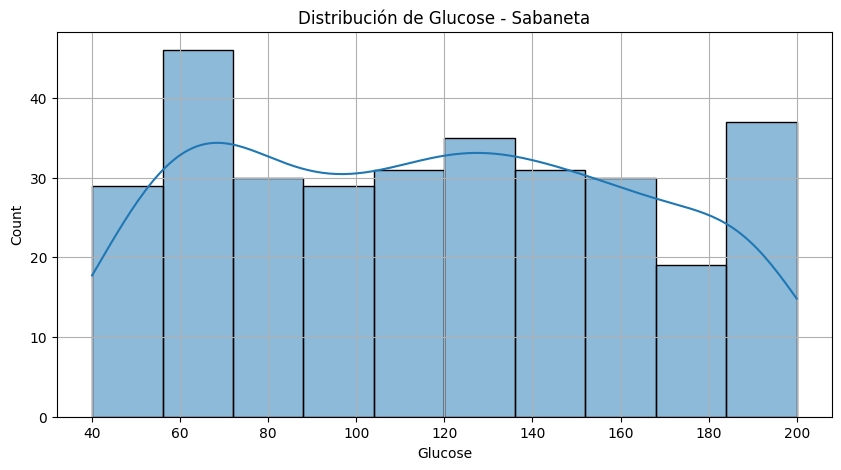

El número de datos por intervalo es:
[29 46 30 29 31 35 31 30 19 37]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  29.0
1   56.0   72.0   64.0  46.0
2   72.0   88.0   80.0  30.0
3   88.0  104.0   96.0  29.0
4  104.0  120.0  112.0  31.0
5  120.0  136.0  128.0  35.0
6  136.0  152.0  144.0  31.0
7  152.0  168.0  160.0  30.0
8  168.0  184.0  176.0  19.0
9  184.0  200.0  192.0  37.0

Media: 117.2997
Desviación Estándar: 46.2627
Coeficiente de Asimetría: 0.1203
Kurtosis: -1.2110


In [5]:
#Caracterización de la sucursal a cerrar: Sabaneta
print("="*60)
print("SUCURSAL A CERRAR: SABANETA")
print("="*60)
u_sab, sigma_sab, Cas_sab, Kur_sab, df_sab = caracterizacion(Glu_sabaneta, "Sabaneta")

SUCURSAL: BELLO


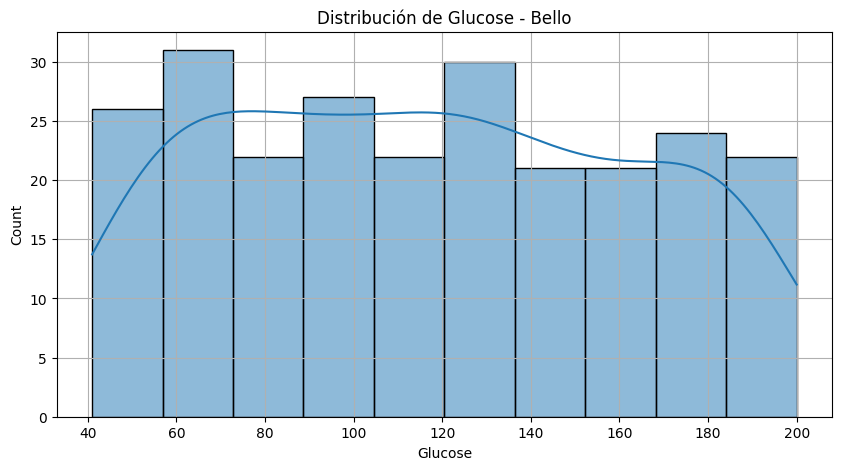

El número de datos por intervalo es:
[26 31 22 27 22 30 21 21 24 22]
Los intervalos inferiores:
[ 41.   56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1]
Los intervalos superiores:
[ 56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1 200. ]

Tabla de frecuencias:
      LI     LS      XC    ND
0   41.0   56.9   48.95  26.0
1   56.9   72.8   64.85  31.0
2   72.8   88.7   80.75  22.0
3   88.7  104.6   96.65  27.0
4  104.6  120.5  112.55  22.0
5  120.5  136.4  128.45  30.0
6  136.4  152.3  144.35  21.0
7  152.3  168.2  160.25  21.0
8  168.2  184.1  176.15  24.0
9  184.1  200.0  192.05  22.0

Media: 117.2683
Desviación Estándar: 45.6224
Coeficiente de Asimetría: 0.0925
Kurtosis: -1.2131


In [6]:
#Caracterización de la sucursal Bello
print("="*60)
print("SUCURSAL: BELLO")
print("="*60)
u_bel, sigma_bel, Cas_bel, Kur_bel, df_bel = caracterizacion(Glu_bello, "Bello")

SUCURSAL: MEDELLÍN


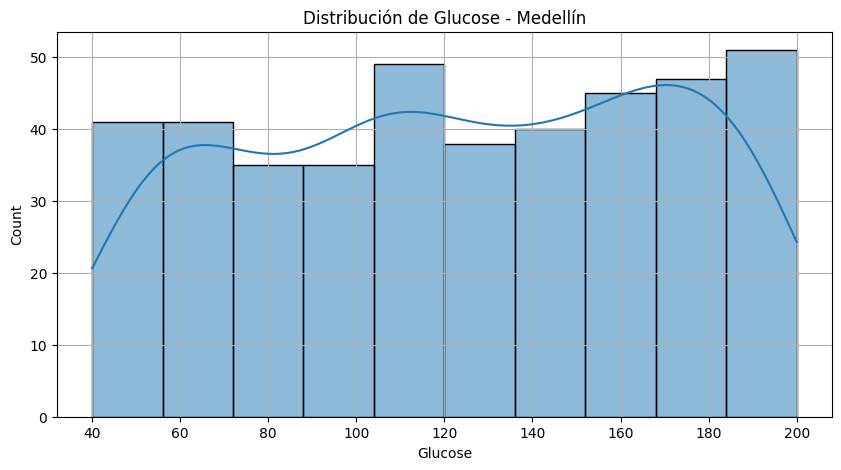

El número de datos por intervalo es:
[41 41 35 35 49 38 40 45 47 51]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  41.0
1   56.0   72.0   64.0  41.0
2   72.0   88.0   80.0  35.0
3   88.0  104.0   96.0  35.0
4  104.0  120.0  112.0  49.0
5  120.0  136.0  128.0  38.0
6  136.0  152.0  144.0  40.0
7  152.0  168.0  160.0  45.0
8  168.0  184.0  176.0  47.0
9  184.0  200.0  192.0  51.0

Media: 123.5261
Desviación Estándar: 46.8034
Coeficiente de Asimetría: -0.0996
Kurtosis: -1.2422


In [7]:
#Caracterización de la sucursal Medellín
print("="*60)
print("SUCURSAL: MEDELLÍN")
print("="*60)
u_med, sigma_med, Cas_med, Kur_med, df_med = caracterizacion(Glu_medellin, "Medellín")

SUCURSAL: ENVIGADO


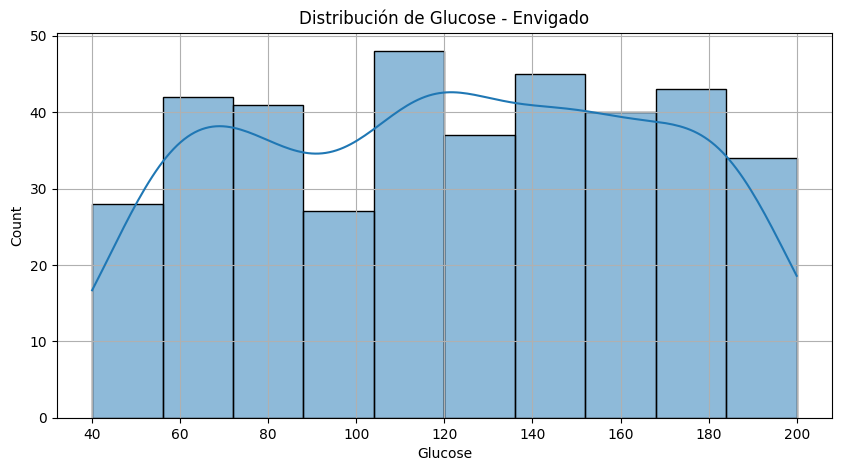

El número de datos por intervalo es:
[28 42 41 27 48 37 45 40 43 34]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  28.0
1   56.0   72.0   64.0  42.0
2   72.0   88.0   80.0  41.0
3   88.0  104.0   96.0  27.0
4  104.0  120.0  112.0  48.0
5  120.0  136.0  128.0  37.0
6  136.0  152.0  144.0  45.0
7  152.0  168.0  160.0  40.0
8  168.0  184.0  176.0  43.0
9  184.0  200.0  192.0  34.0

Media: 122.0571
Desviación Estándar: 44.5133
Coeficiente de Asimetría: -0.0623
Kurtosis: -1.1927


In [8]:
#Caracterización de la sucursal Envigado
print("="*60)
print("SUCURSAL: ENVIGADO")
print("="*60)
u_env, sigma_env, Cas_env, Kur_env, df_env = caracterizacion(Glu_envigado, "Envigado")

SUCURSAL: CALDAS


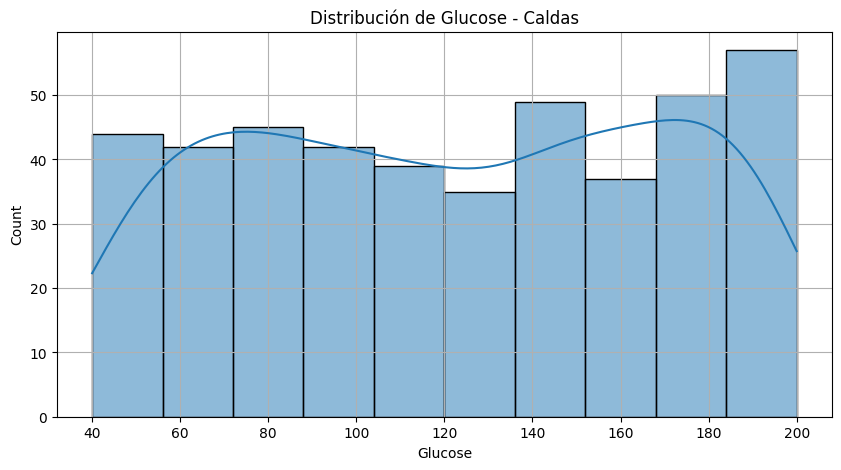

El número de datos por intervalo es:
[44 42 45 42 39 35 49 37 50 57]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  44.0
1   56.0   72.0   64.0  42.0
2   72.0   88.0   80.0  45.0
3   88.0  104.0   96.0  42.0
4  104.0  120.0  112.0  39.0
5  120.0  136.0  128.0  35.0
6  136.0  152.0  144.0  49.0
7  152.0  168.0  160.0  37.0
8  168.0  184.0  176.0  50.0
9  184.0  200.0  192.0  57.0

Media: 122.7273
Desviación Estándar: 47.6058
Coeficiente de Asimetría: -0.0490
Kurtosis: -1.3007


In [9]:
#Caracterización de la sucursal Caldas
print("="*60)
print("SUCURSAL: CALDAS")
print("="*60)
u_cal, sigma_cal, Cas_cal, Kur_cal, df_cal = caracterizacion(Glu_caldas, "Caldas")

### 4. Resumimos las medidas de tendencia central y dispersión antes de la integración

In [10]:
# construimos una tabla resumen con las medidas antes de la integración
resumen_antes = pd.DataFrame({
    'Sucursal': ['Sabaneta', 'Bello', 'Medellín', 'Envigado', 'Caldas'],
    'N Pacientes': [len(Glu_sabaneta), len(Glu_bello), len(Glu_medellin), len(Glu_envigado), len(Glu_caldas)],
    'Media': [u_sab, u_bel, u_med, u_env, u_cal],
    'Desv. Estándar': [sigma_sab, sigma_bel, sigma_med, sigma_env, sigma_cal],
    'Asimetría': [Cas_sab, Cas_bel, Cas_med, Cas_env, Cas_cal],
    'Kurtosis': [Kur_sab, Kur_bel, Kur_med, Kur_env, Kur_cal]
})

print("RESUMEN DE MEDIDAS ANTES DE LA INTEGRACIÓN")
print("="*80)
print(resumen_antes.to_string(index=False))

RESUMEN DE MEDIDAS ANTES DE LA INTEGRACIÓN
Sucursal  N Pacientes      Media  Desv. Estándar  Asimetría  Kurtosis
Sabaneta          317 117.299685       46.262743   0.120317 -1.210967
   Bello          246 117.268293       45.622414   0.092496 -1.213051
Medellín          422 123.526066       46.803441  -0.099559 -1.242168
Envigado          385 122.057143       44.513262  -0.062341 -1.192732
  Caldas          440 122.727273       47.605750  -0.049035 -1.300675


### 5. Hacemos la estimación de la Teoría de la Credibilidad
Se estima la credibilidad entre la sucursal **Sabaneta** (datos internos) y cada una de las demás sucursales (datos externos), para determinar cuál tiene mayor afinidad.

In [12]:
# hacemos la funcion para estimar la credibilidad entre mis datos observados (OBS) y externos (ext)
def credibilidad(LDA_obs, u_obs, sigma_obs, LDA_ext, u_ext, sigma_ext):

    NDo = len(LDA_obs)
    NDe = len(LDA_ext)

    #Se procede con la estimación del Valor Esperado de la Varianza
    EPV = (sigma_obs * NDo + sigma_ext * NDe) / (NDo + NDe)

    #Se procede con la estimación del Valor Hipotético de la Media
    uh = (u_obs * NDo + u_ext * NDe) / (NDo + NDe)
    VHM = ((NDo * u_obs**2 + NDe * u_ext**2) / (NDo + NDe)) - uh**2

    #Se procede con la estimación del factor de credibilidad (fc)
    fc = EPV / VHM

    #Se procede con la estimación de la credibilidad
    Cr = NDo / (NDo + fc)

    return Cr, EPV, VHM, fc

In [13]:
#Se estima la credibilidad entre Sabaneta y cada sucursal
sucursales = ['Bello', 'Medellín', 'Envigado', 'Caldas']
datos_ext = [Glu_bello, Glu_medellin, Glu_envigado, Glu_caldas]
medias_ext = [u_bel, u_med, u_env, u_cal]
sigmas_ext = [sigma_bel, sigma_med, sigma_env, sigma_cal]

credibilidades = []

print("ESTIMACIÓN DE LA CREDIBILIDAD - SABANETA vs CADA SUCURSAL")
print("="*70)
for i in range(len(sucursales)):
    Cr, EPV, VHM, fc = credibilidad(
        Glu_sabaneta, u_sab, sigma_sab,
        datos_ext[i], medias_ext[i], sigmas_ext[i]
    )
    credibilidades.append(Cr)
    print(f"\nSabaneta vs {sucursales[i]}:")
    print(f"  Media Sabaneta: {u_sab:.4f}")
    print(f"  Media {sucursales[i]}: {medias_ext[i]:.4f}")
    print(f"  EPV: {EPV:.4f}")
    print(f"  VHM: {VHM:.4f}")
    print(f"  fc: {fc:.4f}")
    print(f"  Credibilidad: {Cr:.4f} ({Cr*100:.2f}%)")

#Se identifica la sucursal con mayor afinidad
idx_max = np.argmax(credibilidades)
print("\n" + "="*70)
print(f"La sucursal con MAYOR AFINIDAD con Sabaneta es: {sucursales[idx_max]}")
print(f"Con una credibilidad de: {credibilidades[idx_max]*100:.2f}%")

ESTIMACIÓN DE LA CREDIBILIDAD - SABANETA vs CADA SUCURSAL

Sabaneta vs Bello:
  Media Sabaneta: 117.2997
  Media Bello: 117.2683
  EPV: 45.9830
  VHM: 0.0002
  fc: 189664.1288
  Credibilidad: 0.0017 (0.17%)

Sabaneta vs Medellín:
  Media Sabaneta: 117.2997
  Media Medellín: 123.5261
  EPV: 46.5715
  VHM: 9.4963
  fc: 4.9042
  Credibilidad: 0.9848 (98.48%)

Sabaneta vs Envigado:
  Media Sabaneta: 117.2997
  Media Envigado: 122.0571
  EPV: 45.3033
  VHM: 5.6053
  fc: 8.0823
  Credibilidad: 0.9751 (97.51%)

Sabaneta vs Caldas:
  Media Sabaneta: 117.2997
  Media Caldas: 122.7273
  EPV: 47.0434
  VHM: 7.1702
  fc: 6.5609
  Credibilidad: 0.9797 (97.97%)

La sucursal con MAYOR AFINIDAD con Sabaneta es: Medellín
Con una credibilidad de: 98.48%


### 6. Integración de pacientes usando el metodo del Valor de pertenencia
Se procede con la clasificación de los pacientes de Sabaneta en las otras sucursales. Para cada paciente de Sabaneta, se calcula el **Valor de Pertenencia (VP)** respecto a cada sucursal destino. El paciente se asigna a la sucursal donde su VP sea **mayor**.

In [14]:
#Se crean copias de los datos originales para la integración por VP
Glu_bello_VP = np.copy(Glu_bello)
Glu_medellin_VP = np.copy(Glu_medellin)
Glu_envigado_VP = np.copy(Glu_envigado)
Glu_caldas_VP = np.copy(Glu_caldas)

#Contadores de pacientes integrados a cada sucursal
m_bel = 0; m_med = 0; m_env = 0; m_cal = 0

#Se recorren todos los pacientes de Sabaneta
asignaciones_VP = []   #Lista para guardar las asignaciones

for k in range(len(Glu_sabaneta)):

    #Se calcula el VP del paciente respecto a cada sucursal
    VP_bel = np.exp(-0.5 * ((u_bel - Glu_sabaneta[k]) / sigma_bel)**2)
    VP_med = np.exp(-0.5 * ((u_med - Glu_sabaneta[k]) / sigma_med)**2)
    VP_env = np.exp(-0.5 * ((u_env - Glu_sabaneta[k]) / sigma_env)**2)
    VP_cal = np.exp(-0.5 * ((u_cal - Glu_sabaneta[k]) / sigma_cal)**2)

    #Se determina a cuál sucursal tiene mayor pertenencia
    VPs = [VP_bel, VP_med, VP_env, VP_cal]
    nombres = ['Bello', 'Medellín', 'Envigado', 'Caldas']
    idx_mejor = np.argmax(VPs)

    #Se asigna el paciente a la sucursal con mayor VP
    if idx_mejor == 0:
        Glu_bello_VP = np.append(Glu_bello_VP, Glu_sabaneta[k])
        m_bel += 1
    elif idx_mejor == 1:
        Glu_medellin_VP = np.append(Glu_medellin_VP, Glu_sabaneta[k])
        m_med += 1
    elif idx_mejor == 2:
        Glu_envigado_VP = np.append(Glu_envigado_VP, Glu_sabaneta[k])
        m_env += 1
    else:
        Glu_caldas_VP = np.append(Glu_caldas_VP, Glu_sabaneta[k])
        m_cal += 1

    asignaciones_VP.append(nombres[idx_mejor])

print("RESULTADOS DE LA INTEGRACIÓN POR VALOR DE PERTENENCIA")
print("="*60)
print(f"Pacientes integrados a Bello: {m_bel}")
print(f"Pacientes integrados a Medellín: {m_med}")
print(f"Pacientes integrados a Envigado: {m_env}")
print(f"Pacientes integrados a Caldas: {m_cal}")
print(f"Total pacientes integrados: {m_bel + m_med + m_env + m_cal}")

RESULTADOS DE LA INTEGRACIÓN POR VALOR DE PERTENENCIA
Pacientes integrados a Bello: 165
Pacientes integrados a Medellín: 96
Pacientes integrados a Envigado: 6
Pacientes integrados a Caldas: 50
Total pacientes integrados: 317


### 7. Hacemos la validación estadística despues de la integración por Valor de Pertenencia

BELLO - DESPUÉS DE INTEGRACIÓN POR VP


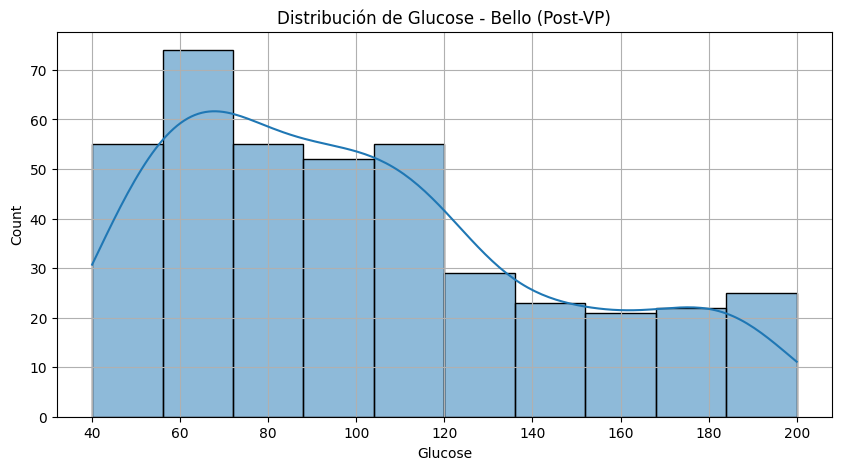

El número de datos por intervalo es:
[55 74 55 52 55 29 23 21 22 25]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  55.0
1   56.0   72.0   64.0  74.0
2   72.0   88.0   80.0  55.0
3   88.0  104.0   96.0  52.0
4  104.0  120.0  112.0  55.0
5  120.0  136.0  128.0  29.0
6  136.0  152.0  144.0  23.0
7  152.0  168.0  160.0  21.0
8  168.0  184.0  176.0  22.0
9  184.0  200.0  192.0  25.0

Media: 102.1509
Desviación Estándar: 42.8603
Coeficiente de Asimetría: 0.6133
Kurtosis: -0.6598


In [15]:
#Se caracterizan las distribuciones después de la integración por VP

# empezamos con bello
print("="*60)
print("BELLO - DESPUÉS DE INTEGRACIÓN POR VP")
print("="*60)
u_bel_VP, sigma_bel_VP, Cas_bel_VP, Kur_bel_VP, df_bel_VP = caracterizacion(Glu_bello_VP, "Bello (Post-VP)")

MEDELLÍN - DESPUÉS DE INTEGRACIÓN POR VP


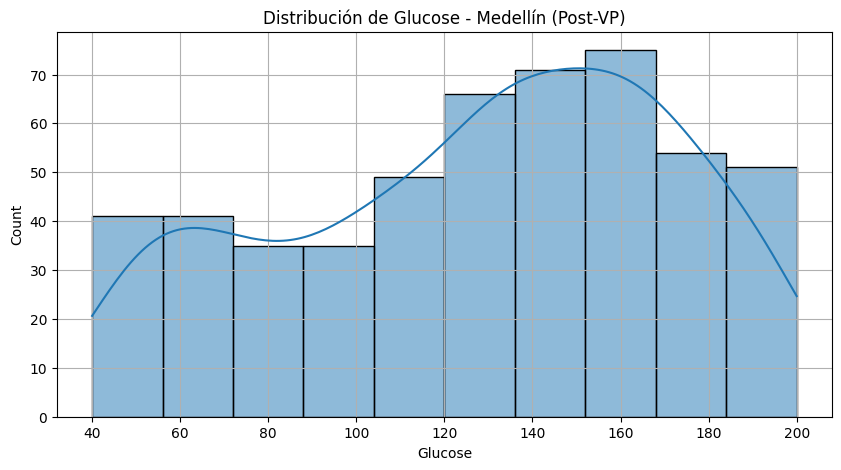

El número de datos por intervalo es:
[41 41 35 35 49 66 71 75 54 51]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  41.0
1   56.0   72.0   64.0  41.0
2   72.0   88.0   80.0  35.0
3   88.0  104.0   96.0  35.0
4  104.0  120.0  112.0  49.0
5  120.0  136.0  128.0  66.0
6  136.0  152.0  144.0  71.0
7  152.0  168.0  160.0  75.0
8  168.0  184.0  176.0  54.0
9  184.0  200.0  192.0  51.0

Media: 127.8147
Desviación Estándar: 43.6649
Coeficiente de Asimetría: -0.3320
Kurtosis: -0.9779


In [16]:
# caracterización medellin
print("="*60)
print("MEDELLÍN - DESPUÉS DE INTEGRACIÓN POR VP")
print("="*60)
u_med_VP, sigma_med_VP, Cas_med_VP, Kur_med_VP, df_med_VP = caracterizacion(Glu_medellin_VP, "Medellín (Post-VP)")

ENVIGADO - DESPUÉS DE INTEGRACIÓN POR VP


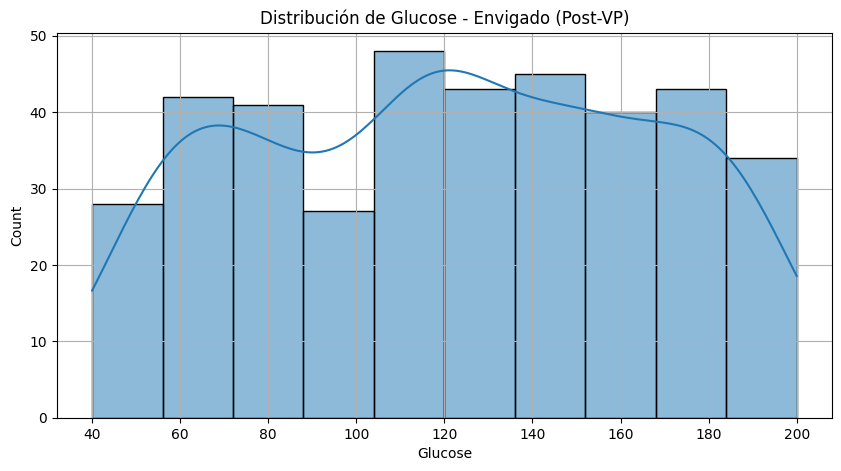

El número de datos por intervalo es:
[28 42 41 27 48 43 45 40 43 34]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  28.0
1   56.0   72.0   64.0  42.0
2   72.0   88.0   80.0  41.0
3   88.0  104.0   96.0  27.0
4  104.0  120.0  112.0  48.0
5  120.0  136.0  128.0  43.0
6  136.0  152.0  144.0  45.0
7  152.0  168.0  160.0  40.0
8  168.0  184.0  176.0  43.0
9  184.0  200.0  192.0  34.0

Media: 122.1483
Desviación Estándar: 44.1764
Coeficiente de Asimetría: -0.0690
Kurtosis: -1.1650


In [17]:
# caracterización envigado
print("="*60)
print("ENVIGADO - DESPUÉS DE INTEGRACIÓN POR VP")
print("="*60)
u_env_VP, sigma_env_VP, Cas_env_VP, Kur_env_VP, df_env_VP = caracterizacion(Glu_envigado_VP, "Envigado (Post-VP)")

CALDAS - DESPUÉS DE INTEGRACIÓN POR VP


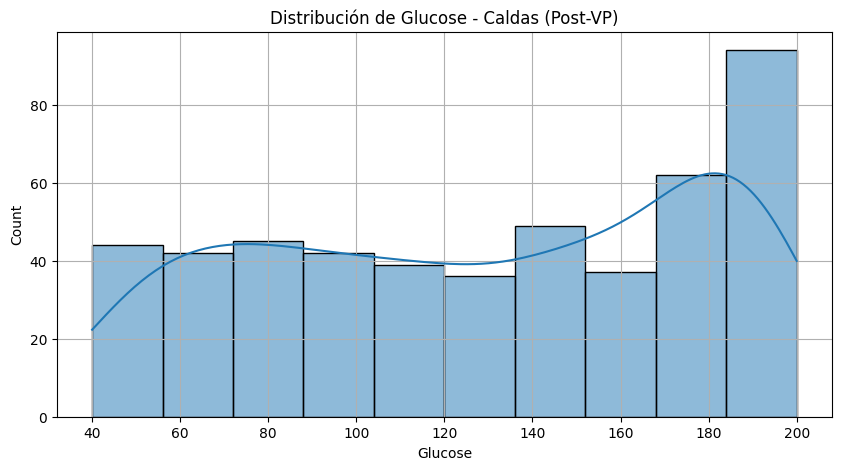

El número de datos por intervalo es:
[44 42 45 42 39 36 49 37 62 94]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  44.0
1   56.0   72.0   64.0  42.0
2   72.0   88.0   80.0  45.0
3   88.0  104.0   96.0  42.0
4  104.0  120.0  112.0  39.0
5  120.0  136.0  128.0  36.0
6  136.0  152.0  144.0  49.0
7  152.0  168.0  160.0  37.0
8  168.0  184.0  176.0  62.0
9  184.0  200.0  192.0  94.0

Media: 129.2735
Desviación Estándar: 49.2352
Coeficiente de Asimetría: -0.1997
Kurtosis: -1.3370


In [18]:
# caracterizacion caldas
print("="*60)
print("CALDAS - DESPUÉS DE INTEGRACIÓN POR VP")
print("="*60)
u_cal_VP, sigma_cal_VP, Cas_cal_VP, Kur_cal_VP, df_cal_VP = caracterizacion(Glu_caldas_VP, "Caldas (Post-VP)")

In [19]:
#Calculamos la discrepancia entre las medidas antes y después de la integración por VP
print("ANÁLISIS DE DISCREPANCIAS - INTEGRACIÓN POR VALOR DE PERTENENCIA")
print("="*80)

print("\nBello:")
disc_u_bel = np.abs((u_bel - u_bel_VP) / u_bel) * 100
disc_s_bel = np.abs((sigma_bel - sigma_bel_VP) / sigma_bel) * 100
print(f"  Media antes: {u_bel:.4f} | Media después: {u_bel_VP:.4f} | Discrepancia: {disc_u_bel:.4f}%")
print(f"  Sigma antes: {sigma_bel:.4f} | Sigma después: {sigma_bel_VP:.4f} | Discrepancia: {disc_s_bel:.4f}%")

print("\nMedellín:")
disc_u_med = np.abs((u_med - u_med_VP) / u_med) * 100
disc_s_med = np.abs((sigma_med - sigma_med_VP) / sigma_med) * 100
print(f"  Media antes: {u_med:.4f} | Media después: {u_med_VP:.4f} | Discrepancia: {disc_u_med:.4f}%")
print(f"  Sigma antes: {sigma_med:.4f} | Sigma después: {sigma_med_VP:.4f} | Discrepancia: {disc_s_med:.4f}%")

print("\nEnvigado:")
disc_u_env = np.abs((u_env - u_env_VP) / u_env) * 100
disc_s_env = np.abs((sigma_env - sigma_env_VP) / sigma_env) * 100
print(f"  Media antes: {u_env:.4f} | Media después: {u_env_VP:.4f} | Discrepancia: {disc_u_env:.4f}%")
print(f"  Sigma antes: {sigma_env:.4f} | Sigma después: {sigma_env_VP:.4f} | Discrepancia: {disc_s_env:.4f}%")

print("\nCaldas:")
disc_u_cal = np.abs((u_cal - u_cal_VP) / u_cal) * 100
disc_s_cal = np.abs((sigma_cal - sigma_cal_VP) / sigma_cal) * 100
print(f"  Media antes: {u_cal:.4f} | Media después: {u_cal_VP:.4f} | Discrepancia: {disc_u_cal:.4f}%")
print(f"  Sigma antes: {sigma_cal:.4f} | Sigma después: {sigma_cal_VP:.4f} | Discrepancia: {disc_s_cal:.4f}%")

ANÁLISIS DE DISCREPANCIAS - INTEGRACIÓN POR VALOR DE PERTENENCIA

Bello:
  Media antes: 117.2683 | Media después: 102.1509 | Discrepancia: 12.8913%
  Sigma antes: 45.6224 | Sigma después: 42.8603 | Discrepancia: 6.0542%

Medellín:
  Media antes: 123.5261 | Media después: 127.8147 | Discrepancia: 3.4718%
  Sigma antes: 46.8034 | Sigma después: 43.6649 | Discrepancia: 6.7058%

Envigado:
  Media antes: 122.0571 | Media después: 122.1483 | Discrepancia: 0.0747%
  Sigma antes: 44.5133 | Sigma después: 44.1764 | Discrepancia: 0.7567%

Caldas:
  Media antes: 122.7273 | Media después: 129.2735 | Discrepancia: 5.3339%
  Sigma antes: 47.6058 | Sigma después: 49.2352 | Discrepancia: 3.4229%


### 8. Resumimos la comparacion de antes y despues que acabamos de hacer

In [20]:
#Tabla resumen después de la integración por VP
resumen_despues_VP = pd.DataFrame({
    'Sucursal': ['Bello', 'Medellín', 'Envigado', 'Caldas'],
    'N Antes': [len(Glu_bello), len(Glu_medellin), len(Glu_envigado), len(Glu_caldas)],
    'N Después': [len(Glu_bello_VP), len(Glu_medellin_VP), len(Glu_envigado_VP), len(Glu_caldas_VP)],
    'Integrados': [m_bel, m_med, m_env, m_cal],
    'Media Antes': [u_bel, u_med, u_env, u_cal],
    'Media Después': [u_bel_VP, u_med_VP, u_env_VP, u_cal_VP],
    'Disc. Media %': [disc_u_bel, disc_u_med, disc_u_env, disc_u_cal],
    'Sigma Antes': [sigma_bel, sigma_med, sigma_env, sigma_cal],
    'Sigma Después': [sigma_bel_VP, sigma_med_VP, sigma_env_VP, sigma_cal_VP],
    'Disc. Sigma %': [disc_s_bel, disc_s_med, disc_s_env, disc_s_cal]
})

print("TABLA RESUMEN - INTEGRACIÓN POR VALOR DE PERTENENCIA")
print("="*120)
print(resumen_despues_VP.to_string(index=False))

TABLA RESUMEN - INTEGRACIÓN POR VALOR DE PERTENENCIA
Sucursal  N Antes  N Después  Integrados  Media Antes  Media Después  Disc. Media %  Sigma Antes  Sigma Después  Disc. Sigma %
   Bello      246        411         165   117.268293     102.150852      12.891329    45.622414      42.860342       6.054201
Medellín      422        518          96   123.526066     127.814672       3.471822    46.803441      43.664883       6.705828
Envigado      385        391           6   122.057143     122.148338       0.074715    44.513262      44.176448       0.756660
  Caldas      440        490          50   122.727273     129.273469       5.333938    47.605750      49.235240       3.422885


### 9. Integración de pacientes mediante el Método de Aceptación y Rechazo
Se procede con la integración de los pacientes de Sabaneta a **cada sucursal** utilizando el método de Aceptación y Rechazo. Para cada sucursal destino, se evalúa el VP de cada dato externo (Sabaneta) respecto a la distribución de la sucursal. Si el **VP > 0.9**, el dato es **aceptado** (integrado); de lo contrario, es **rechazado**.

In [21]:
#Se crean copias de los datos originales para la integración por Aceptación/Rechazo
Glu_bello_AR = np.copy(Glu_bello)
Glu_medellin_AR = np.copy(Glu_medellin)
Glu_envigado_AR = np.copy(Glu_envigado)
Glu_caldas_AR = np.copy(Glu_caldas)

#Umbral de aceptación
umbral = 0.9

#Se integran los datos de Sabaneta en cada sucursal por Aceptación/Rechazo
print("INTEGRACIÓN POR ACEPTACIÓN Y RECHAZO")
print("="*60)

#--- Integración a Bello ---
m1_bel = 0
for k in range(len(Glu_sabaneta)):
    VP = np.exp(-0.5 * ((u_bel - Glu_sabaneta[k]) / sigma_bel)**2)
    if VP > umbral:
        m1_bel += 1
        Glu_bello_AR = np.append(Glu_bello_AR, Glu_sabaneta[k])

print(f"\nBello: {m1_bel} datos aceptados de {len(Glu_sabaneta)}")

#--- Integración a Medellín ---
m1_med = 0
for k in range(len(Glu_sabaneta)):
    VP = np.exp(-0.5 * ((u_med - Glu_sabaneta[k]) / sigma_med)**2)
    if VP > umbral:
        m1_med += 1
        Glu_medellin_AR = np.append(Glu_medellin_AR, Glu_sabaneta[k])

print(f"Medellín: {m1_med} datos aceptados de {len(Glu_sabaneta)}")

#--- Integración a Envigado ---
m1_env = 0
for k in range(len(Glu_sabaneta)):
    VP = np.exp(-0.5 * ((u_env - Glu_sabaneta[k]) / sigma_env)**2)
    if VP > umbral:
        m1_env += 1
        Glu_envigado_AR = np.append(Glu_envigado_AR, Glu_sabaneta[k])

print(f"Envigado: {m1_env} datos aceptados de {len(Glu_sabaneta)}")

#--- Integración a Caldas ---
m1_cal = 0
for k in range(len(Glu_sabaneta)):
    VP = np.exp(-0.5 * ((u_cal - Glu_sabaneta[k]) / sigma_cal)**2)
    if VP > umbral:
        m1_cal += 1
        Glu_caldas_AR = np.append(Glu_caldas_AR, Glu_sabaneta[k])

print(f"Caldas: {m1_cal} datos aceptados de {len(Glu_sabaneta)}")

INTEGRACIÓN POR ACEPTACIÓN Y RECHAZO

Bello: 83 datos aceptados de 317
Medellín: 89 datos aceptados de 317
Envigado: 86 datos aceptados de 317
Caldas: 90 datos aceptados de 317


### 10. Hacemos la validación estadística despues de la integración por Aceptación y Rechazo

BELLO - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO


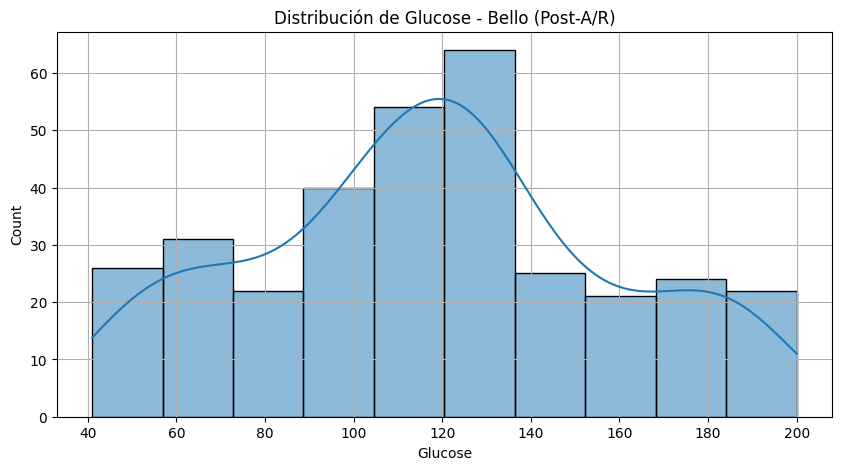

El número de datos por intervalo es:
[26 31 22 40 54 64 25 21 24 22]
Los intervalos inferiores:
[ 41.   56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1]
Los intervalos superiores:
[ 56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1 200. ]

Tabla de frecuencias:
      LI     LS      XC    ND
0   41.0   56.9   48.95  26.0
1   56.9   72.8   64.85  31.0
2   72.8   88.7   80.75  22.0
3   88.7  104.6   96.65  40.0
4  104.6  120.5  112.55  54.0
5  120.5  136.4  128.45  64.0
6  136.4  152.3  144.35  25.0
7  152.3  168.2  160.25  21.0
8  168.2  184.1  176.15  24.0
9  184.1  200.0  192.05  22.0

Media: 117.4795
Desviación Estándar: 39.9633
Coeficiente de Asimetría: 0.0875
Kurtosis: -0.7266


In [22]:
#Se caracterizan las distribuciones después de la integración por Aceptación/Rechazo
print("="*60)
print("BELLO - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO")
print("="*60)
u_bel_AR, sigma_bel_AR, Cas_bel_AR, Kur_bel_AR, df_bel_AR = caracterizacion(Glu_bello_AR, "Bello (Post-A/R)")

MEDELLÍN - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO


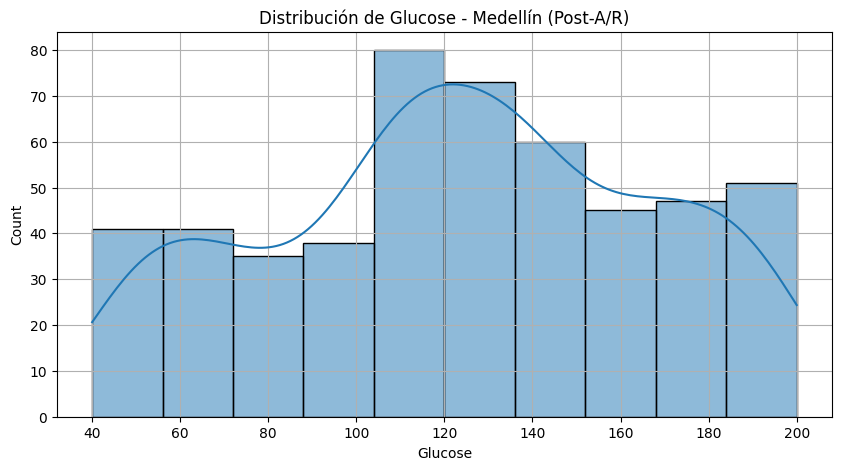

El número de datos por intervalo es:
[41 41 35 38 80 73 60 45 47 51]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  41.0
1   56.0   72.0   64.0  41.0
2   72.0   88.0   80.0  35.0
3   88.0  104.0   96.0  38.0
4  104.0  120.0  112.0  80.0
5  120.0  136.0  128.0  73.0
6  136.0  152.0  144.0  60.0
7  152.0  168.0  160.0  45.0
8  168.0  184.0  176.0  47.0
9  184.0  200.0  192.0  51.0

Media: 123.7730
Desviación Estándar: 42.8866
Coeficiente de Asimetría: -0.1225
Kurtosis: -0.9348


In [23]:
# caracterizacion Medellín
print("="*60)
print("MEDELLÍN - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO")
print("="*60)
u_med_AR, sigma_med_AR, Cas_med_AR, Kur_med_AR, df_med_AR = caracterizacion(Glu_medellin_AR, "Medellín (Post-A/R)")

ENVIGADO - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO


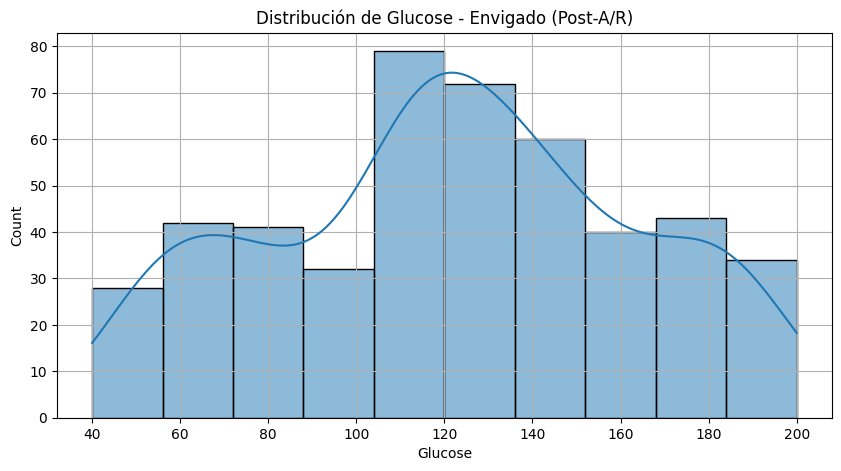

El número de datos por intervalo es:
[28 42 41 32 79 72 60 40 43 34]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  28.0
1   56.0   72.0   64.0  42.0
2   72.0   88.0   80.0  41.0
3   88.0  104.0   96.0  32.0
4  104.0  120.0  112.0  79.0
5  120.0  136.0  128.0  72.0
6  136.0  152.0  144.0  60.0
7  152.0  168.0  160.0  40.0
8  168.0  184.0  176.0  43.0
9  184.0  200.0  192.0  34.0

Media: 122.2590
Desviación Estándar: 40.6377
Coeficiente de Asimetría: -0.0804
Kurtosis: -0.8671


In [24]:
# caracterización envigado
print("="*60)
print("ENVIGADO - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO")
print("="*60)
u_env_AR, sigma_env_AR, Cas_env_AR, Kur_env_AR, df_env_AR = caracterizacion(Glu_envigado_AR, "Envigado (Post-A/R)")

CALDAS - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO


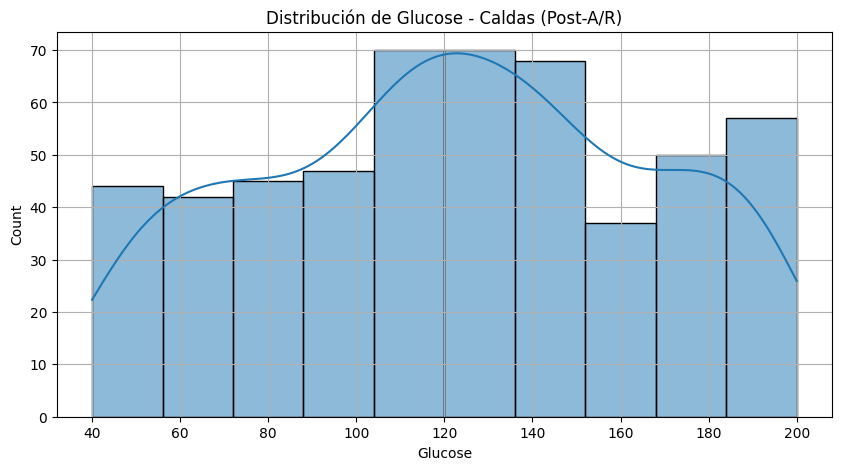

El número de datos por intervalo es:
[44 42 45 47 70 70 68 37 50 57]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]

Tabla de frecuencias:
      LI     LS     XC    ND
0   40.0   56.0   48.0  44.0
1   56.0   72.0   64.0  42.0
2   72.0   88.0   80.0  45.0
3   88.0  104.0   96.0  47.0
4  104.0  120.0  112.0  70.0
5  120.0  136.0  128.0  70.0
6  136.0  152.0  144.0  68.0
7  152.0  168.0  160.0  37.0
8  168.0  184.0  176.0  50.0
9  184.0  200.0  192.0  57.0

Media: 122.9585
Desviación Estándar: 43.7371
Coeficiente de Asimetría: -0.0671
Kurtosis: -1.0151


In [25]:
# caracterizacion caldas
print("="*60)
print("CALDAS - DESPUÉS DE INTEGRACIÓN POR ACEPTACIÓN/RECHAZO")
print("="*60)
u_cal_AR, sigma_cal_AR, Cas_cal_AR, Kur_cal_AR, df_cal_AR = caracterizacion(Glu_caldas_AR, "Caldas (Post-A/R)")

In [26]:
#Se calcula la discrepancia entre las medidas antes y después de la integración por aceptacion/rechazo
print("ANÁLISIS DE DISCREPANCIAS - INTEGRACIÓN POR ACEPTACIÓN Y RECHAZO")
print("="*80)

print("\nBello:")
disc_u_bel_AR = np.abs((u_bel - u_bel_AR) / u_bel) * 100
disc_s_bel_AR = np.abs((sigma_bel - sigma_bel_AR) / sigma_bel) * 100
print(f"  Media antes: {u_bel:.4f} | Media después: {u_bel_AR:.4f} | Discrepancia: {disc_u_bel_AR:.4f}%")
print(f"  Sigma antes: {sigma_bel:.4f} | Sigma después: {sigma_bel_AR:.4f} | Discrepancia: {disc_s_bel_AR:.4f}%")

print("\nMedellín:")
disc_u_med_AR = np.abs((u_med - u_med_AR) / u_med) * 100
disc_s_med_AR = np.abs((sigma_med - sigma_med_AR) / sigma_med) * 100
print(f"  Media antes: {u_med:.4f} | Media después: {u_med_AR:.4f} | Discrepancia: {disc_u_med_AR:.4f}%")
print(f"  Sigma antes: {sigma_med:.4f} | Sigma después: {sigma_med_AR:.4f} | Discrepancia: {disc_s_med_AR:.4f}%")

print("\nEnvigado:")
disc_u_env_AR = np.abs((u_env - u_env_AR) / u_env) * 100
disc_s_env_AR = np.abs((sigma_env - sigma_env_AR) / sigma_env) * 100
print(f"  Media antes: {u_env:.4f} | Media después: {u_env_AR:.4f} | Discrepancia: {disc_u_env_AR:.4f}%")
print(f"  Sigma antes: {sigma_env:.4f} | Sigma después: {sigma_env_AR:.4f} | Discrepancia: {disc_s_env_AR:.4f}%")

print("\nCaldas:")
disc_u_cal_AR = np.abs((u_cal - u_cal_AR) / u_cal) * 100
disc_s_cal_AR = np.abs((sigma_cal - sigma_cal_AR) / sigma_cal) * 100
print(f"  Media antes: {u_cal:.4f} | Media después: {u_cal_AR:.4f} | Discrepancia: {disc_u_cal_AR:.4f}%")
print(f"  Sigma antes: {sigma_cal:.4f} | Sigma después: {sigma_cal_AR:.4f} | Discrepancia: {disc_s_cal_AR:.4f}%")

ANÁLISIS DE DISCREPANCIAS - INTEGRACIÓN POR ACEPTACIÓN Y RECHAZO

Bello:
  Media antes: 117.2683 | Media después: 117.4795 | Discrepancia: 0.1801%
  Sigma antes: 45.6224 | Sigma después: 39.9633 | Discrepancia: 12.4042%

Medellín:
  Media antes: 123.5261 | Media después: 123.7730 | Discrepancia: 0.1999%
  Sigma antes: 46.8034 | Sigma después: 42.8866 | Discrepancia: 8.3687%

Envigado:
  Media antes: 122.0571 | Media después: 122.2590 | Discrepancia: 0.1654%
  Sigma antes: 44.5133 | Sigma después: 40.6377 | Discrepancia: 8.7065%

Caldas:
  Media antes: 122.7273 | Media después: 122.9585 | Discrepancia: 0.1884%
  Sigma antes: 47.6058 | Sigma después: 43.7371 | Discrepancia: 8.1263%


## 11. resumimos la comparacion de antes y despues de Aceptación y Rechazo

In [27]:
#Tabla resumen después de la integración por Aceptación/Rechazo
resumen_despues_AR = pd.DataFrame({
    'Sucursal': ['Bello', 'Medellín', 'Envigado', 'Caldas'],
    'N Antes': [len(Glu_bello), len(Glu_medellin), len(Glu_envigado), len(Glu_caldas)],
    'N Después': [len(Glu_bello_AR), len(Glu_medellin_AR), len(Glu_envigado_AR), len(Glu_caldas_AR)],
    'Aceptados': [m1_bel, m1_med, m1_env, m1_cal],
    'Media Antes': [u_bel, u_med, u_env, u_cal],
    'Media Después': [u_bel_AR, u_med_AR, u_env_AR, u_cal_AR],
    'Disc. Media %': [disc_u_bel_AR, disc_u_med_AR, disc_u_env_AR, disc_u_cal_AR],
    'Sigma Antes': [sigma_bel, sigma_med, sigma_env, sigma_cal],
    'Sigma Después': [sigma_bel_AR, sigma_med_AR, sigma_env_AR, sigma_cal_AR],
    'Disc. Sigma %': [disc_s_bel_AR, disc_s_med_AR, disc_s_env_AR, disc_s_cal_AR]
})

print("TABLA RESUMEN - INTEGRACIÓN POR ACEPTACIÓN Y RECHAZO")
print("="*120)
print(resumen_despues_AR.to_string(index=False))

TABLA RESUMEN - INTEGRACIÓN POR ACEPTACIÓN Y RECHAZO
Sucursal  N Antes  N Después  Aceptados  Media Antes  Media Después  Disc. Media %  Sigma Antes  Sigma Después  Disc. Sigma %
   Bello      246        329         83   117.268293     117.479483       0.180092    45.622414      39.963299      12.404244
Medellín      422        511         89   123.526066     123.772994       0.199899    46.803441      42.886590       8.368724
Envigado      385        471         86   122.057143     122.259023       0.165398    44.513262      40.637709       8.706514
  Caldas      440        530         90   122.727273     122.958491       0.188400    47.605750      43.737146       8.126339


### 12. Análisis Comparativo Final
Comparación de ambos métodos de integración.

In [28]:
print("COMPARACIÓN FINAL DE MÉTODOS DE INTEGRACIÓN")
print("="*80)

print("\n--- MÉTODO 1: VALOR DE PERTENENCIA ---")
print(f"Pacientes integrados a Bello: {m_bel}")
print(f"Pacientes integrados a Medellín: {m_med}")
print(f"Pacientes integrados a Envigado: {m_env}")
print(f"Pacientes integrados a Caldas: {m_cal}")
print(f"TOTAL: {m_bel + m_med + m_env + m_cal} (todos los pacientes son reasignados)")

print("\n--- MÉTODO 2: ACEPTACIÓN Y RECHAZO (Umbral VP > 0.9) ---")
print(f"Pacientes aceptados en Bello: {m1_bel}")
print(f"Pacientes aceptados en Medellín: {m1_med}")
print(f"Pacientes aceptados en Envigado: {m1_env}")
print(f"Pacientes aceptados en Caldas: {m1_cal}")
total_AR = m1_bel + m1_med + m1_env + m1_cal
print(f"TOTAL aceptados: {total_AR}")
print(f"TOTAL rechazados: {len(Glu_sabaneta) - max(m1_bel, m1_med, m1_env, m1_cal)} (por sucursal individual)")

print("\n--- DISCREPANCIA PROMEDIO EN MEDIA ---")
print(f"Valor de Pertenencia: {np.mean([disc_u_bel, disc_u_med, disc_u_env, disc_u_cal]):.4f}%")
print(f"Aceptación y Rechazo: {np.mean([disc_u_bel_AR, disc_u_med_AR, disc_u_env_AR, disc_u_cal_AR]):.4f}%")

print("\n--- DISCREPANCIA PROMEDIO EN DESVIACIÓN ESTÁNDAR ---")
print(f"Valor de Pertenencia: {np.mean([disc_s_bel, disc_s_med, disc_s_env, disc_s_cal]):.4f}%")
print(f"Aceptación y Rechazo: {np.mean([disc_s_bel_AR, disc_s_med_AR, disc_s_env_AR, disc_s_cal_AR]):.4f}%")

COMPARACIÓN FINAL DE MÉTODOS DE INTEGRACIÓN

--- MÉTODO 1: VALOR DE PERTENENCIA ---
Pacientes integrados a Bello: 165
Pacientes integrados a Medellín: 96
Pacientes integrados a Envigado: 6
Pacientes integrados a Caldas: 50
TOTAL: 317 (todos los pacientes son reasignados)

--- MÉTODO 2: ACEPTACIÓN Y RECHAZO (Umbral VP > 0.9) ---
Pacientes aceptados en Bello: 83
Pacientes aceptados en Medellín: 89
Pacientes aceptados en Envigado: 86
Pacientes aceptados en Caldas: 90
TOTAL aceptados: 348
TOTAL rechazados: 227 (por sucursal individual)

--- DISCREPANCIA PROMEDIO EN MEDIA ---
Valor de Pertenencia: 5.4430%
Aceptación y Rechazo: 0.1834%

--- DISCREPANCIA PROMEDIO EN DESVIACIÓN ESTÁNDAR ---
Valor de Pertenencia: 4.2349%
Aceptación y Rechazo: 9.4015%


### Análisis de los Datos
De lo anterior podemos observar lo siguiente:

**1. Antes de la integración:** Las cinco sucursales tienen distribuciones bastante parecidas en cuanto a Glucose de los pacientes diabéticos. Las medias van desde 117.27 (Bello) hasta 123.53 (Medellín), y las desviaciones estándar están todas entre 44 y 47. Lo más interesante es que Sabaneta (media de 117.30) y Bello (media de 117.27) tienen medias casi idénticas, con una diferencia de apenas 0.03. Medellín, Envigado y Caldas están un poco más arriba en media, entre 122 y 123. Itagüí se excluyó del análisis porque no tiene la variable Glucose en su base de datos.

**2. Credibilidad:** Acá pasó algo curioso. La credibilidad entre Sabaneta y Bello dio apenas 0.17%, lo cual no significa que sean incompatibles, sino todo lo contrario: como sus medias son prácticamente iguales, el VHM da casi cero y eso hace que el fc se dispare a 189,664, lo que baja la credibilidad numéricamente. Esto confirma que Bello es la sucursal con mayor afinidad con Sabaneta. Por otro lado, Medellín dio 98.48%, Caldas 97.97% y Envigado 97.51%, lo que nos dice que aunque sus medias son un poco más altas, sus distribuciones siguen siendo compatibles para integrar datos.

**3. Integración por Valor de Pertenencia:** Con este método se reasignaron los 317 pacientes de Sabaneta al 100%. La mayoría se fue a Bello (165 pacientes, o sea el 52%), seguido de Medellín (96), Caldas (50) y Envigado que solo recibió 6. El problema es que Bello al recibir tantos pacientes tuvo una discrepancia en la media del 12.89%, que es bastante alta. Medellín tuvo 3.47%, Caldas 5.33% y Envigado casi nada (0.07%) porque recibió muy pocos. En promedio la discrepancia en media fue de 5.44% y en desviación estándar de 4.23%.

**4. Integración por Aceptación y Rechazo:** Este método fue más parejo. Con un umbral de VP > 0.9, cada sucursal aceptó entre 83 y 90 pacientes (Bello 83, Medellín 89, Envigado 86, Caldas 90). La gran ventaja es que la discrepancia en la media fue mínima en todas las sucursales, menor al 0.20%, lo cual es excelente. Sin embargo, la desviación estándar sí se vio más afectada (entre 8% y 12% de discrepancia), porque al aceptar solo datos cercanos a la media, la distribución se vuelve menos dispersa.

**5. Comparación final:** Básicamente, el método de Valor de Pertenencia garantiza que todos los pacientes queden reubicados pero afecta más las medidas estadísticas de las sucursales (sobre todo Bello). El método de Aceptación y Rechazo mantiene mucho mejor la estabilidad de la media (0.18% vs 5.44% de discrepancia promedio), pero no reubica a todos los pacientes y reduce un poco la dispersión. Al final la decisión depende de qué priorice la entidad de salud: si quiere reubicar a todos los pacientes usa Valor de Pertenencia, y si quiere mantener la estabilidad estadística de cada sucursal usa Aceptación y Rechazo. Asumiendo que por temas legales, la entidad debe reasignar a todos los pacientes, el metodo debe ser el Valor de Pertenencia.